Importing Libs and Files

In [80]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Reading Dataset

In [31]:
import os

path = "../data/raw/heart_disease_uci.csv"

os.path.abspath(path=path)
df_raw = pd.read_csv(path)

df = df_raw.copy()


In [33]:
print(f"Shape dos dados: {df.shape}")
print(f"\nPrimeiras linhas do dataset:")
df.head(10)

Shape dos dados: (920, 16)

Primeiras linhas do dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [37]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [53]:
# Count missing values per column
missing_per_column = df.isnull().sum()
# print("Missing values per column:")#
# print(missing_per_column)
columns = df.columns
total_rows = df.id.value_counts().sum()

for index, counts in enumerate(missing_per_column):

    pc = counts / total_rows * 100

    print(f'Col: {columns[index]} - Missing Values: {counts} - Percentage: {pc}%')

# Total missing values

total_missing = df.isnull().sum().sum()
print(f"\nTotal missing values: {total_missing}")

Col: id - Missing Values: 0 - Percentage: 0.0%
Col: age - Missing Values: 0 - Percentage: 0.0%
Col: sex - Missing Values: 0 - Percentage: 0.0%
Col: dataset - Missing Values: 0 - Percentage: 0.0%
Col: cp - Missing Values: 0 - Percentage: 0.0%
Col: trestbps - Missing Values: 59 - Percentage: 6.41304347826087%
Col: chol - Missing Values: 30 - Percentage: 3.260869565217391%
Col: fbs - Missing Values: 90 - Percentage: 9.782608695652174%
Col: restecg - Missing Values: 2 - Percentage: 0.21739130434782608%
Col: thalch - Missing Values: 55 - Percentage: 5.978260869565218%
Col: exang - Missing Values: 55 - Percentage: 5.978260869565218%
Col: oldpeak - Missing Values: 62 - Percentage: 6.739130434782608%
Col: slope - Missing Values: 309 - Percentage: 33.58695652173913%
Col: ca - Missing Values: 611 - Percentage: 66.41304347826087%
Col: thal - Missing Values: 486 - Percentage: 52.826086956521735%
Col: num - Missing Values: 0 - Percentage: 0.0%

Total missing values: 1759


In [60]:
# Distribuição da variável target

# Renomear variável `num` para `target`
df.rename(columns={'num': 'target'}, inplace=True)

df.target.value_counts() # Valores de 1 a 4

# Conversão para 0 ou 1

df['target'] = (df['target'] > 0)

df.target.value_counts(normalize=True) * 100 # Valores binários



target
True     55.326087
False    44.673913
Name: proportion, dtype: float64

In [64]:
print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100
# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("✓ Dataset razoavelmente balanceado.")

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Ratio de balanceamento: 0.81
✓ Dataset razoavelmente balanceado.


Análise de Outliers

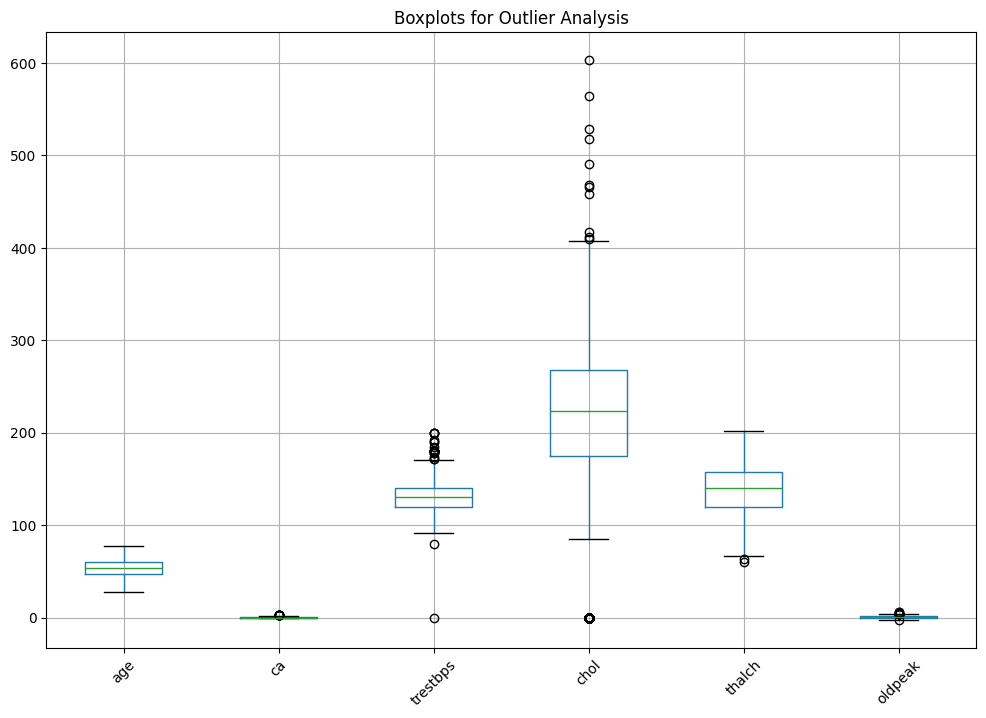

In [68]:


# Select numerical columns for outlier analysis
numerical_cols = ['age', 'ca', 'trestbps', 'chol', 'thalch', 'oldpeak']

# Create boxplots for each numerical column
df[numerical_cols].boxplot(figsize=(12, 8))
plt.title('Boxplots for Outlier Analysis')
plt.xticks(rotation=45)
plt.show()

In [69]:

# Analyze columns for disruptive data in the context of heart disease prediction

# Define expected ranges or conditions for key columns
invalid_data = {}

# Age: should be between 0 and 120
invalid_age = df[(df['age'] < 0) | (df['age'] > 120)]
if not invalid_age.empty:
    invalid_data['age'] = invalid_age[['id', 'age']]

# Resting blood pressure (trestbps): should be positive
invalid_trestbps = df[df['trestbps'] < 0]
if not invalid_trestbps.empty:
    invalid_data['trestbps'] = invalid_trestbps[['id', 'trestbps']]

# Serum cholesterol (chol): should be positive
invalid_chol = df[df['chol'] < 0]
if not invalid_chol.empty:
    invalid_data['chol'] = invalid_chol[['id', 'chol']]

# Maximum heart rate (thalch): should be positive
invalid_thalch = df[df['thalch'] < 0]
if not invalid_thalch.empty:
    invalid_data['thalch'] = invalid_thalch[['id', 'thalch']]

# ST depression (oldpeak): should be non-negative
invalid_oldpeak = df[df['oldpeak'] < 0]
if not invalid_oldpeak.empty:
    invalid_data['oldpeak'] = invalid_oldpeak[['id', 'oldpeak']]

# Number of major vessels (ca): should be 0-3 (assuming typical range)
invalid_ca = df[(df['ca'] < 0) | (df['ca'] > 3)]
if not invalid_ca.empty:
    invalid_data['ca'] = invalid_ca[['id', 'ca']]

# Print summary of disruptive data
if invalid_data:
    print("Disruptive data found:")
    for col, data in invalid_data.items():
        print(f"\nColumn '{col}': {len(data)} invalid entries")
        print(data.head())
else:
    print("No obvious disruptive data found in the analyzed columns.")

Disruptive data found:

Column 'oldpeak': 12 invalid entries
      id  oldpeak
603  604     -1.1
609  610     -1.5
614  615     -0.1
615  616     -2.6
629  630     -0.7


In [75]:
print("=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===\n")

# Verificações de consistência baseadas em conhecimento de domínio
anomalies = []

# 1. Idade (deve estar entre 0 e 120)
age_anomalies = df[(df['age'] < 0) | (df['age'] > 120)]
if len(age_anomalies) > 0:
    anomalies.append(f"Idade fora do intervalo válido: {len(age_anomalies)} casos")
    
# 2. Pressão arterial (trestbps) - valores típicos: 80-200 mmHg
bp_anomalies = df[(df['trestbps'] < 80) | (df['trestbps'] > 200)]
if len(bp_anomalies) > 0:
    anomalies.append(f"Pressão arterial anormal: {len(bp_anomalies)} casos")
    print(f"⚠️ Pressão arterial anormal detectada: {len(bp_anomalies)} casos")
    print(f"   Valores: min={df['trestbps'].min()}, max={df['trestbps'].max()}")

# 3. Colesterol (chol) - valores típicos: 100-400 mg/dl
chol_anomalies = df[(df['chol'] < 100) | (df['chol'] > 400)]
if len(chol_anomalies) > 0:
    anomalies.append(f"Colesterol anormal: {len(chol_anomalies)} casos")
    print(f"⚠️ Colesterol anormal detectado: {len(chol_anomalies)} casos")
    print(f"   Valores: min={df['chol'].min()}, max={df['chol'].max()}")

# 4. Frequência cardíaca máxima (thalch) - valores típicos: 60-220 bpm
hr_anomalies = df[(df['thalch'] < 60) | (df['thalch'] > 220)]
if len(hr_anomalies) > 0:
    anomalies.append(f"Frequência cardíaca anormal: {len(hr_anomalies)} casos")
    print(f"⚠️ Frequência cardíaca anormal detectada: {len(hr_anomalies)} casos")
    print(f"   Valores: min={df['thalch'].min()}, max={df['thalch'].max()}")

# 5. Variáveis categóricas com valores fora do esperado
categorical_checks = {
    'sex': [0, 1],
    'cp': [0, 1, 2, 3],
    'fbs': [0, 1],
    'restecg': [0, 1, 2],
    'exang': [0, 1],
    'slope': [0, 1, 2],
    'ca': [0, 1, 2, 3, 4],
    'thal': [0, 1, 2, 3]
}

for col, valid_values in categorical_checks.items():
    if col in df.columns:
        invalid = df[~df[col].isin(valid_values) & df[col].notna()]
        if len(invalid) > 0:
            anomalies.append(f"{col}: {len(invalid)} valores inválidos")
            print(f"⚠️ {col}: {len(invalid)} valores fora do domínio esperado {valid_values}")

if len(anomalies) == 0:
    print("✓ Nenhuma anomalia óbvia detectada nas validações de domínio!")
else:
    print(f"\n📊 Total de tipos de anomalias detectadas: {len(anomalies)}")

# Verificar duplicados
duplicates = df.duplicated().sum()
print(f"\n=== DUPLICADOS ===")
print(f"Registros duplicados: {duplicates}")
if duplicates > 0:
    print("⚠️ Considere remover ou investigar registros duplicados")

=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===

⚠️ Pressão arterial anormal detectada: 1 casos
   Valores: min=0.0, max=200.0
⚠️ Colesterol anormal detectado: 186 casos
   Valores: min=0.0, max=603.0
⚠️ sex: 920 valores fora do domínio esperado [0, 1]
⚠️ cp: 920 valores fora do domínio esperado [0, 1, 2, 3]
⚠️ restecg: 918 valores fora do domínio esperado [0, 1, 2]
⚠️ slope: 611 valores fora do domínio esperado [0, 1, 2]
⚠️ thal: 434 valores fora do domínio esperado [0, 1, 2, 3]

📊 Total de tipos de anomalias detectadas: 7

=== DUPLICADOS ===
Registros duplicados: 0


=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

  Coluna  Skewness  Kurtosis          Interpretação
     age    -0.196    -0.383                 Normal
trestbps     0.213     2.959                 Normal
    chol    -0.614     0.062 Assimétrica à esquerda
  thalch    -0.211    -0.480                 Normal
 oldpeak     1.041     1.127  Assimétrica à direita
      ca     1.166     0.199  Assimétrica à direita


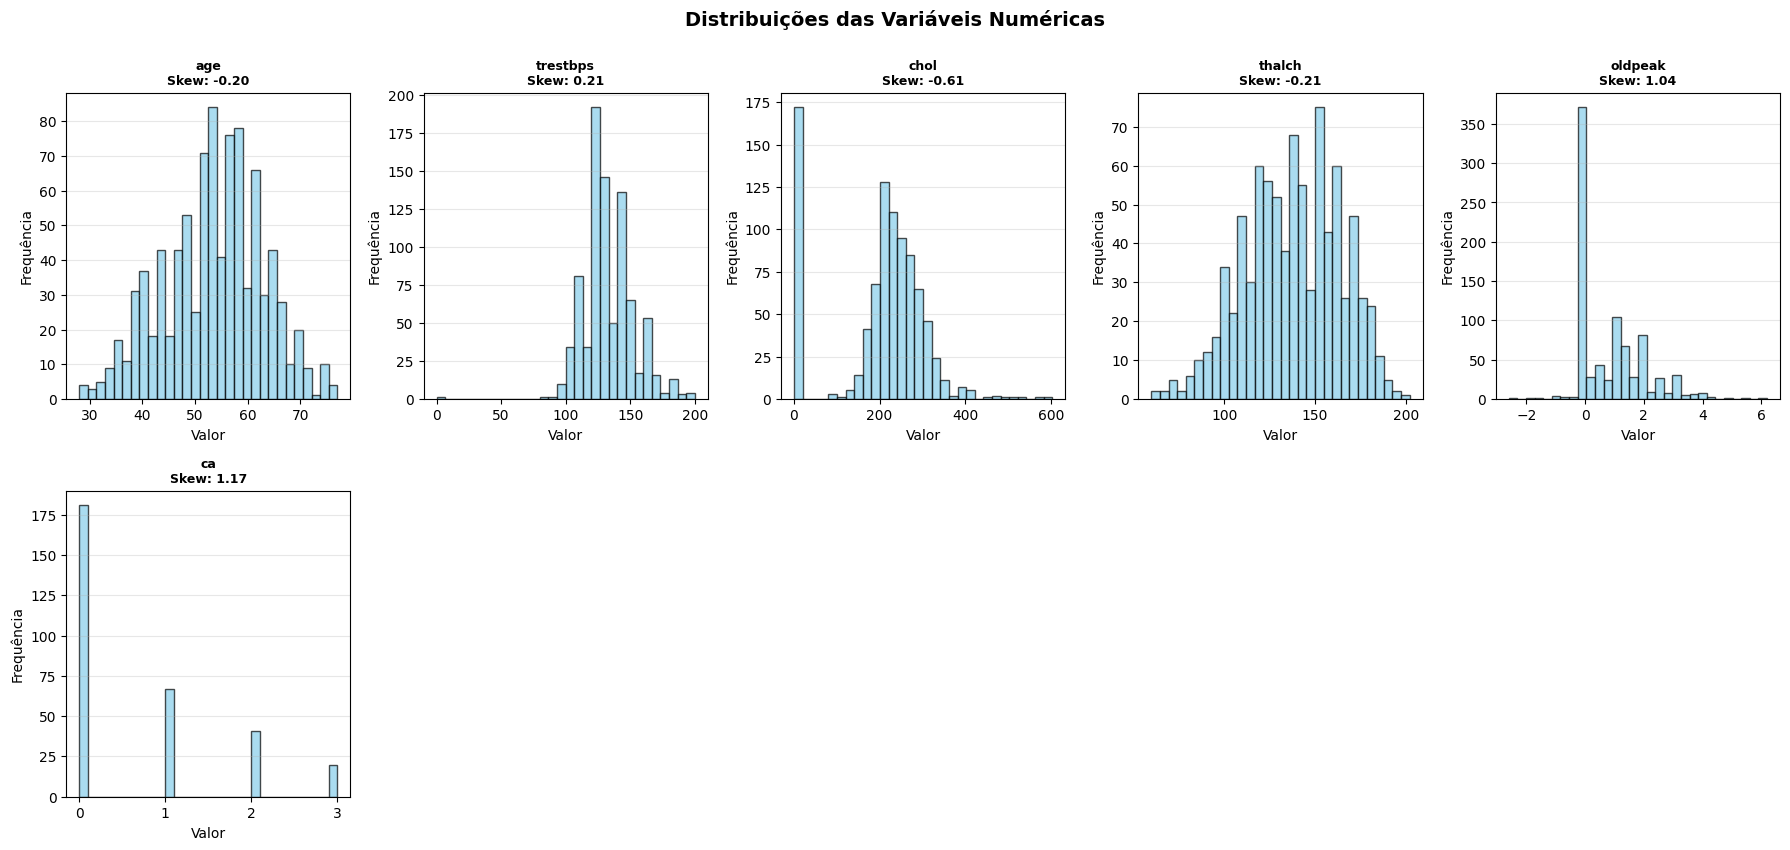

In [77]:
# Análise de distribuições
print("=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")
# Colunas numéricas (excluindo id e target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['id'])
distribution_stats = []
for col in numeric_cols:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    distribution_stats.append({
        'Coluna': col,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita' if skewness > 0 else 'Assimétrica à esquerda')
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

# Visualizar distribuições
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {df[col].skew():.2f}', fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(axis='y', alpha=0.3)

# Remover subplots vazios
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuições das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

<Figure size 1400x1000 with 0 Axes>

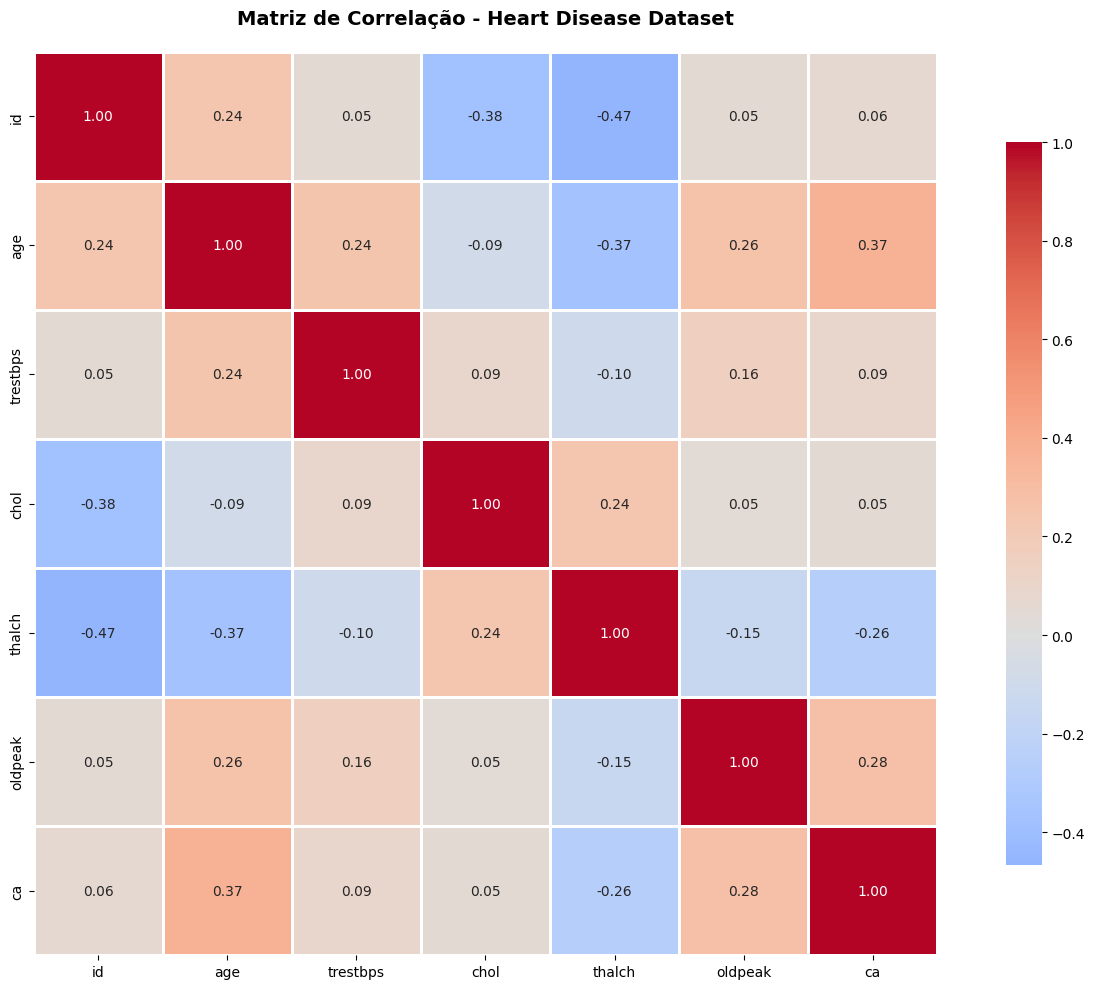

=== CORRELAÇÕES COM A VARIÁVEL TARGET ===



KeyError: 'target'

In [82]:

# Matriz de correlação apenas para colunas numéricas
corr_numeric = df.select_dtypes(include=[np.number]).corr()

# Visualizar matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Heart Disease Dataset', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlações fortes com o target
print("=== CORRELAÇÕES COM A VARIÁVEL TARGET ===\n")
target_corr = corr_numeric['target'].sort_values(ascending=False)
print(target_corr)

# Identificar pares de features com alta correlação (possível multicolinearidade)
print("\n=== MULTICOLINEARIDADE (Correlação entre features) ===")
print("Pares de features com correlação > 0.7:\n")

high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'target' and corr_numeric.columns[j] != 'target':
            high_corr_pairs.append({
                'Feature 1': corr_numeric.columns[i],
                'Feature 2': corr_numeric.columns[j],
                'Correlação': round(corr_numeric.iloc[i, j], 3)
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlação', ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\n⚠️ Alta correlação entre features pode causar multicolinearidade!")
else:
    print("✓ Nenhuma correlação forte detectada entre features (excluindo target)")